# اليوم الأول: فهم البيانات وتحليلها استكشافيًا

هذا الدفتر يحافظ على الهدف الأصلي، وينشئ هدفًا ثنائيًا منفصلًا، ويسجل القيم المفقودة دون معالجتها.

## الخلية 1: تثبيت واستيراد المكتبات

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## الخلية 2: تحميل البيانات

In [ ]:
url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart_disease_cleveland.csv"

try:
    df = pd.read_csv(url)
    print("تم تحميل البيانات بنجاح ✅")
except Exception:
    print("فشل تحميل الرابط الأول، سيتم استخدام رابط UCI المباشر")
    url2 = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    columns = [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
    ]
    df = pd.read_csv(url2, names=columns, na_values="?")
    print("تم تحميل البيانات من UCI مباشرة ✅")

فشل تحميل الرابط الأول، سيتم استخدام رابط UCI المباشر
تم تحميل البيانات من UCI مباشرة ✅


## الخلية 3: الاحتفاظ بالهدف الأصلي وإنشاء هدف ثنائي

In [ ]:
# نغيّر اسم عمود الهدف الأصلي إلى num حتى لا نفقد درجات الإصابة الأصلية.
df.rename(columns={"target": "num"}, inplace=True)

# نسخة خام تُحفظ كما هي قبل أي معالجة.
raw_df = df.copy()

# 0 = غير مصاب، 1 = مصاب بأي درجة.
df["target_binary"] = (df["num"] > 0).astype(int)

print("توزيع الهدف الثنائي:")
print(df["target_binary"].value_counts())
print("\nالنسب المئوية:")
print((df["target_binary"].value_counts(normalize=True) * 100).round(1))

توزيع الهدف الثنائي:
target_binary
0    164
1    139
Name: count, dtype: int64

النسب المئوية:
target_binary
0    54.1
1    45.9
Name: proportion, dtype: float64


## الخلية 4: نظرة أولى على البيانات

In [ ]:
print("عدد الصفوف والأعمدة:", df.shape)
display(df.head(10))

عدد الصفوف والأعمدة: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1,1


## الخلية 5: معلومات عامة عن الأعمدة

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            303 non-null    float64
 1   sex            303 non-null    float64
 2   cp             303 non-null    float64
 3   trestbps       303 non-null    float64
 4   chol           303 non-null    float64
 5   fbs            303 non-null    float64
 6   restecg        303 non-null    float64
 7   thalach        303 non-null    float64
 8   exang          303 non-null    float64
 9   oldpeak        303 non-null    float64
 10  slope          303 non-null    float64
 11  ca             299 non-null    float64
 12  thal           301 non-null    float64
 13  num            303 non-null    int64  
 14  target_binary  303 non-null    int64  
dtypes: float64(13), int64(2)
memory usage: 35.6 KB


## الخلية 6: إحصاءات وصفية

In [ ]:
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


## الخلية 7: فحص القيم المفقودة

In [ ]:
missing_values = df.isnull().sum()
print("عدد القيم المفقودة في كل عمود:")
print(missing_values)
print("\nإجمالي القيم المفقودة:", int(missing_values.sum()))

عدد القيم المفقودة في كل عمود:
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               4
thal             2
num              0
target_binary    0
dtype: int64

إجمالي القيم المفقودة: 6


## الخلية 8: فحص الصفوف المكررة

In [ ]:
duplicate_rows = df.duplicated().sum()
print("عدد الصفوف المكررة:", duplicate_rows)

عدد الصفوف المكررة: 0


## الخلية 9: توزيع المتغير الهدف

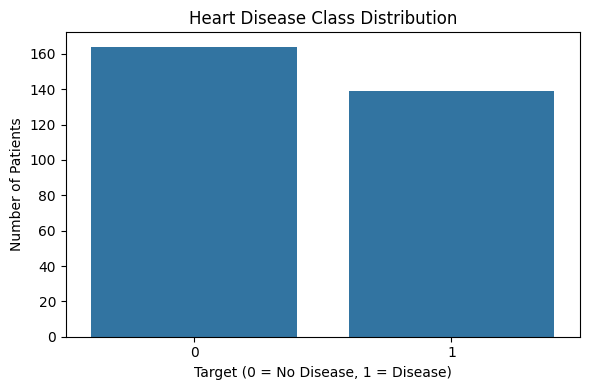

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target_binary", data=df)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

## الخلية 10: توزيع الأعمار

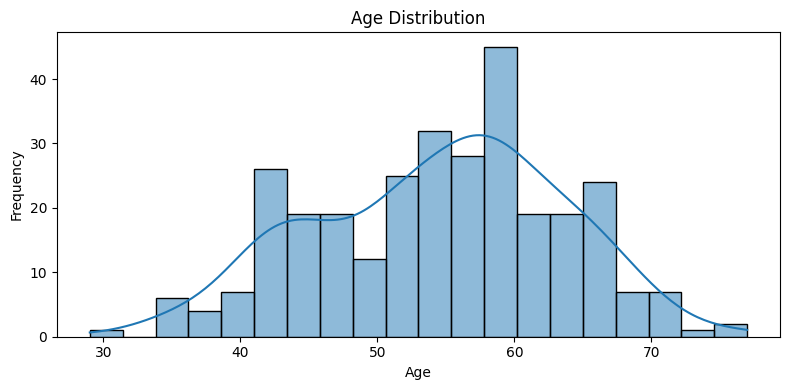

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## الخلية 11: العلاقة بين العمر والإصابة

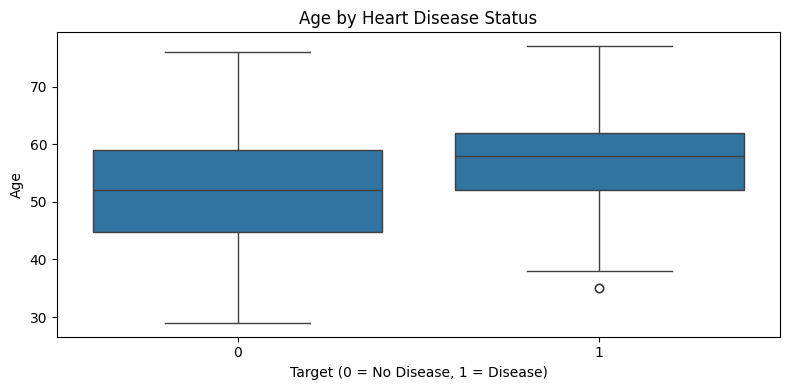

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="target_binary", y="age", data=df)
plt.title("Age by Heart Disease Status")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

## الخلية 12: خريطة الارتباط

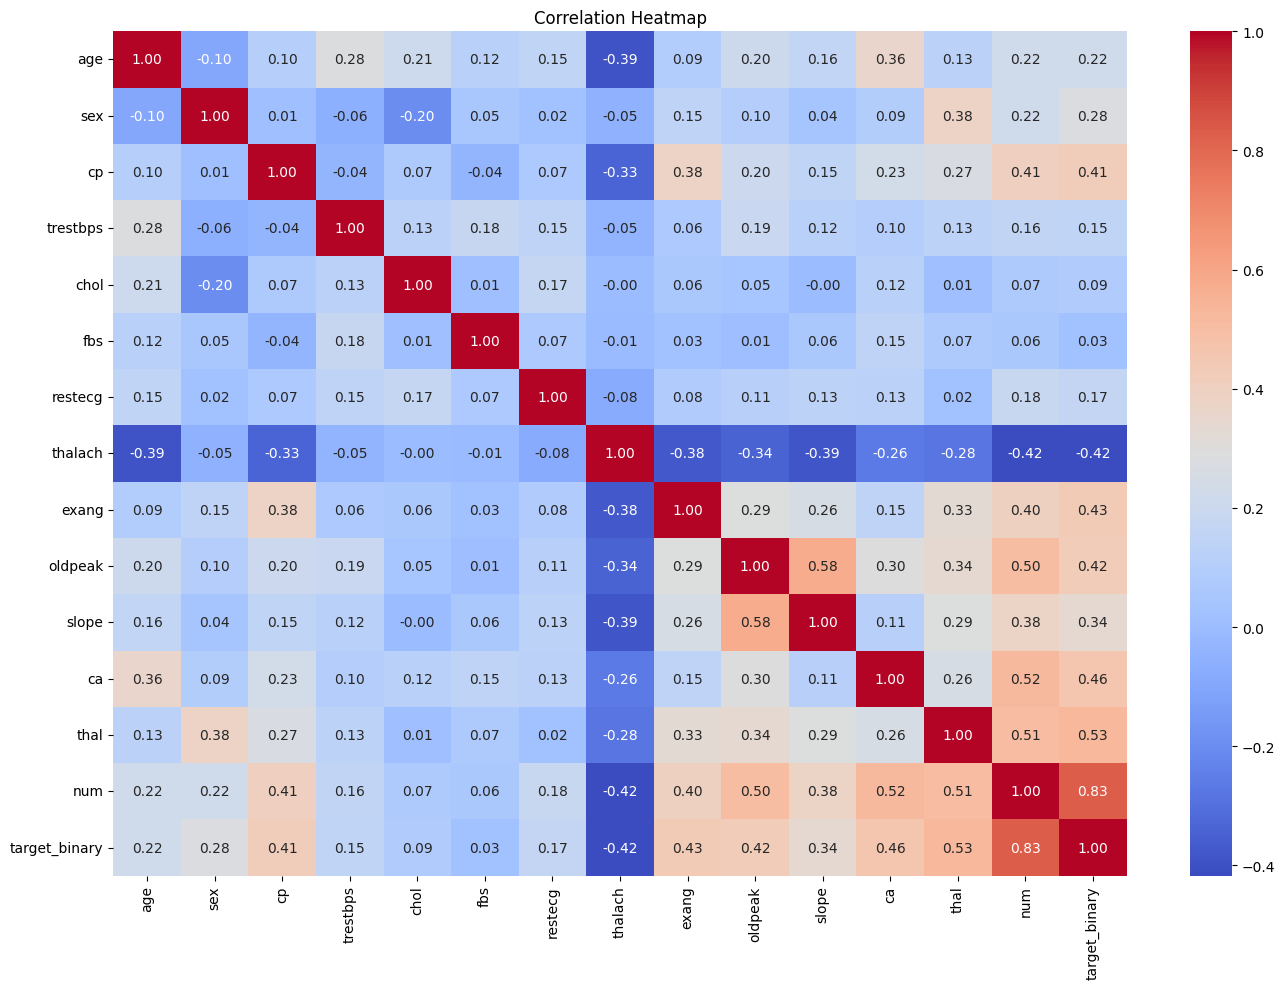

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## الخلية 13: حفظ البيانات الأصلية

In [ ]:
# لا نسمّيها بيانات نظيفة لأن القيم المفقودة لم تُعالج بعد.
raw_df.to_csv("heart_disease_raw.csv", index=False)
print("تم حفظ البيانات الأصلية باسم heart_disease_raw.csv")

تم حفظ البيانات الأصلية باسم heart_disease_raw.csv


## الخلية 14: خلاصة فهم البيانات

In [ ]:
summary = """
تحتوي مجموعة البيانات على 303 سجلات و13 خاصية إدخال.
توجد ست قيم مفقودة: أربع في ca واثنتان في thal، ولا توجد صفوف مكررة.
بعد تحويل الهدف إلى تصنيف ثنائي، بلغ عدد الحالات غير المصابة 164
مقابل 139 حالة مصابة؛ ولذلك تعد الفئتان متوازنتين بدرجة مناسبة.
"""
print(summary)

# ============================================================
# مهام استكمال اليوم الأول:
# 1. تحديث وثيقة المشروع الحالية بدل تسميتها "مقترح مشروع"، لأن التنفيذ بدأ.
# 2. تنظيم مستودع GitHub ورفع ملف 01_data_understanding.ipynb.
# 3. استكمال ملخص الدراسة السابقة وربطه بمشكلة المشروع وأهدافه.
# ============================================================


تحتوي مجموعة البيانات على 303 سجلات و13 خاصية إدخال.
توجد ست قيم مفقودة: أربع في ca واثنتان في thal، ولا توجد صفوف مكررة.
بعد تحويل الهدف إلى تصنيف ثنائي، بلغ عدد الحالات غير المصابة 164
مقابل 139 حالة مصابة؛ ولذلك تعد الفئتان متوازنتين بدرجة مناسبة.

